In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys
import os

# Adicionar o caminho para o diretorio src
sys.path.append(os.path.abspath('../src'))

# Importar as classes de raiz
from utils import prepare_text_data
from neuralnet import NeuralNetwork
from layers import DenseLayer, DropoutLayer
from activations import ReLUActivation, SoftmaxActivation
from losses import CategoricalCrossEntropy
from optimizer import Adam

In [2]:
# Carregar o dataset
df = pd.read_csv('../data/dataset.csv').dropna()

textos = df['text'].tolist()
labels = df['label'].tolist()

# Pipeline combinado: Word TF-IDF (3000) + Char TF-IDF (3000) + 13 features estilisticas
X_train, Y_train, X_val, Y_val, X_test, Y_test, transformers, encoder = prepare_text_data(
    textos, 
    labels, 
    max_features=3000,     # Word TF-IDF features
    char_features=3000,    # Char TF-IDF features (padroes de caracteres)
    test_size=0.2,     
    val_size=0.1,      
    use_stratify=True,
    ngram_range=(1, 2)
)

print(f"Setup Concluido!")
print(f"Train: {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}")
print(f"Total features: {X_train.shape[1]} (word tfidf + char tfidf + estilisticas)")
print(f"Classes: {encoder.categories_[0]}")

Setup Concluido!
Train: (1721, 6013) | Val: (246, 6013) | Test: (493, 6013)
Total features: 6013 (word tfidf + char tfidf + estilisticas)
Classes: ['anthropic' 'google' 'human' 'meta' 'openai']


In [3]:
# Definir dimensoes
input_dim = X_train.shape[1]  # ~6013 features combinadas
output_dim = Y_train.shape[1]  # 5 classes

# Adam com learning rate controlado
adam = Adam(learning_rate=0.0005)

# Rede ajustada ao tamanho das features
nn = NeuralNetwork(loss_func=CategoricalCrossEntropy())

# Camada 1: Input -> 256
nn.add(DenseLayer(input_shape=input_dim, n_units=256, optimizer=adam))
nn.add(ReLUActivation())
nn.add(DropoutLayer(rate=0.5))

# Camada 2: 256 -> 64
nn.add(DenseLayer(input_shape=256, n_units=64, optimizer=adam))
nn.add(ReLUActivation())
nn.add(DropoutLayer(rate=0.3))

# Camada de Saida: 64 -> 5
nn.add(DenseLayer(input_shape=64, n_units=output_dim, optimizer=adam))
nn.add(SoftmaxActivation())

print(f"Rede montada: {input_dim} -> 256 -> 64 -> {output_dim}")
print(f"Optimizer: Adam (lr=0.0005) | Dropout: 0.5/0.3")

Rede montada: 6013 -> 256 -> 64 -> 5
Optimizer: Adam (lr=0.0005) | Dropout: 0.5/0.3


In [4]:
epochs = 300
batch_size = 32

print("A iniciar o treino...")
nn.fit(
    X_train, Y_train,
    epochs=epochs,
    batch_size=batch_size,
    verbose=True,
    X_val=X_val, Y_val=Y_val,
    patience=50  # Muito mais paciente - so para depois de 50 epocas sem melhoria
)

A iniciar o treino...
Epoch 1/300 | Loss: 1.3486 | Val Loss: 1.3781 | Train Acc: 55.03% | Val Acc: 47.15%
Epoch 11/300 | Loss: 0.0375 | Val Loss: 1.1348 | Train Acc: 99.94% | Val Acc: 57.72%
Epoch 21/300 | Loss: 0.0026 | Val Loss: 1.5133 | Train Acc: 100.00% | Val Acc: 56.91%
Epoch 31/300 | Loss: 0.0006 | Val Loss: 1.7845 | Train Acc: 100.00% | Val Acc: 57.32%
Epoch 41/300 | Loss: 0.0003 | Val Loss: 1.8882 | Train Acc: 100.00% | Val Acc: 55.28%
Epoch 51/300 | Loss: 0.0001 | Val Loss: 2.0352 | Train Acc: 100.00% | Val Acc: 54.88%

Early Stopping na epoca 56! Val Loss nao melhorou ha 50 epocas.
Melhor Val Loss: 0.9204
Melhores pesos restaurados.


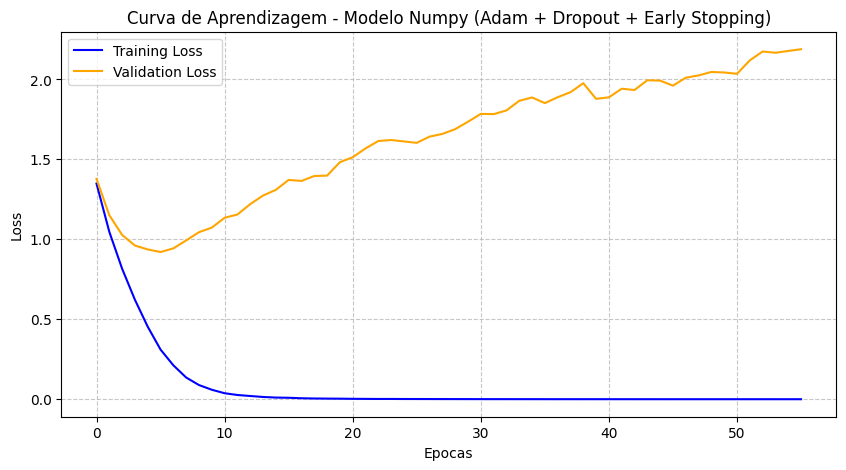

Resultados do Modelo Numpy (com melhores pesos):
  Train  - Loss: 0.3105 | Accuracy: 95.53%
  Val    - Loss: 0.9204 | Accuracy: 62.20%
  Teste  - Loss: 0.8778 | Accuracy: 63.69%


In [5]:
# 1. Desenhar as curvas de Loss (treino + validacao)
plt.figure(figsize=(10, 5))
plt.plot(nn.history['loss'], label='Training Loss', color='blue')
if nn.history['val_loss']:
    plt.plot(nn.history['val_loss'], label='Validation Loss', color='orange')
plt.title('Curva de Aprendizagem - Modelo Numpy (Adam + Dropout + Early Stopping)')
plt.xlabel('Epocas')
plt.ylabel('Loss')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

# 2. Avaliar nos dados de teste
test_loss, test_acc = nn.evaluate(X_test, Y_test)
val_loss, val_acc = nn.evaluate(X_val, Y_val)
train_loss, train_acc = nn.evaluate(X_train, Y_train)

print(f"Resultados do Modelo Numpy (com melhores pesos):")
print(f"  Train  - Loss: {train_loss:.4f} | Accuracy: {train_acc*100:.2f}%")
print(f"  Val    - Loss: {val_loss:.4f} | Accuracy: {val_acc*100:.2f}%")
print(f"  Teste  - Loss: {test_loss:.4f} | Accuracy: {test_acc*100:.2f}%")

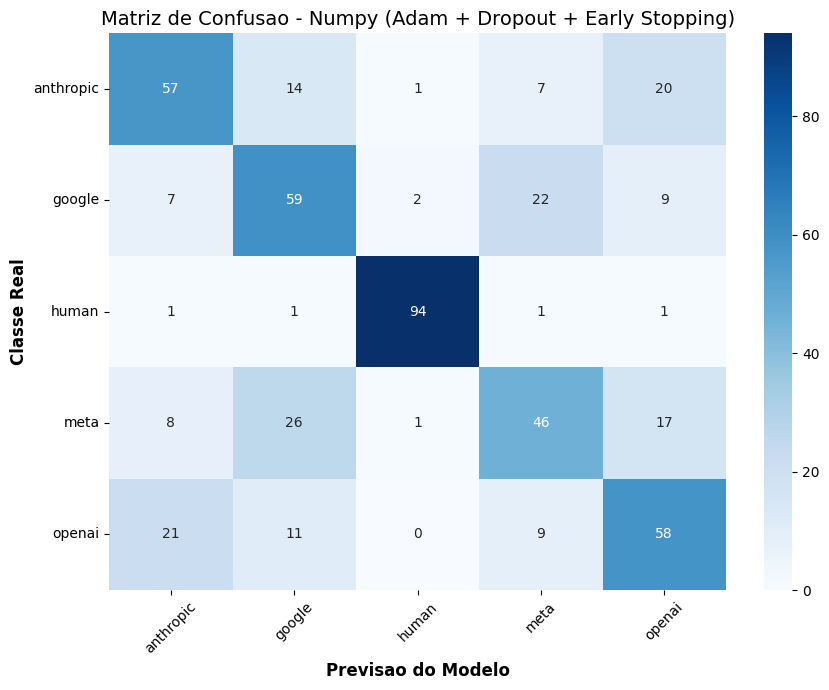


Classification Report:
              precision    recall  f1-score   support

   anthropic       0.61      0.58      0.59        99
      google       0.53      0.60      0.56        99
       human       0.96      0.96      0.96        98
        meta       0.54      0.47      0.50        98
      openai       0.55      0.59      0.57        99

    accuracy                           0.64       493
   macro avg       0.64      0.64      0.64       493
weighted avg       0.64      0.64      0.64       493



In [6]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# 1. Obter previsoes
y_pred_proba = nn.predict(X_test)

# 2. Converter de One-Hot para indices
y_pred = np.argmax(y_pred_proba, axis=1)
y_true = np.argmax(Y_test, axis=1)

# 3. Matriz de confusao
cm = confusion_matrix(y_true, y_pred)
class_names = encoder.categories_[0]

plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Previsao do Modelo', fontsize=12, fontweight='bold')
plt.ylabel('Classe Real', fontsize=12, fontweight='bold')
plt.title('Matriz de Confusao - Numpy (Adam + Dropout + Early Stopping)', fontsize=14)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# 4. Classification Report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))